# Projeto Final - Sistema de Inspeção, Controle e Monitoramento com Algoritmos Computacionais

**Discentes:**  
- Gabriel Vilela Firmo — NUSP: 17425965  
- Murilo Couto de Oliveira — NUSP: 15622926

---

## Universidade de São Paulo
- Instituto de Ciências Matemáticas e de Computação – ICMC
- Disciplina: MAI5001 – Introdução à Ciência de Computação
- Semestre: 2º Semestre de 2025
- Docente: Prof. Dr. Claudio Fabiano Motta Toledo

---

## Descrição Geral

O trabalho desenvolve um sistema computacional de inspeção, controle de estoque e monitoramento de desempenho, implementado em Python de forma modular. Fluxograma resumido do projeto:

```mermaid
flowchart LR
    A[Início da Simulação] --> B[Gerador de Dados]
    B -->|Lista de produtos - tipo 1 e 2| C[Módulo de Inspeção]

    C --> C1[InspecaoTipo1]
    C --> C2[InspecaoTipo2]

    C1 --> D[Lista de produtos inspecionados - tempo calculado]
    C2 --> D

    D --> E[Módulo de Controle de Estoque]
    E --> E1[Inserir produtos inspecionados - por cliente]
    E --> E2[Buscar produto pelo par - cliente, tamanho]

    E1 --> F[Módulo de Monitoramento]
    E2 --> F

    C --> F

    F --> G[Gráficos de desempenho - Tipo 1, Tipo 2, Controle]

    G --> H[Fim da Simulação]
```

---

## Objetivos do Trabalho

- Modelar de forma computacional um sistema simplificado de inspeção, controle de estoque e monitoramento, utilizando conceitos de algoritmos e estruturas de dados.

- Implementar módulos independentes para geração de dados, inspeção de produtos, controle via tabela hash e monitoramento de métricas de desempenho.

- Aplicar e comparar dois algoritmos de inspeção (Tipo 1, O(n), e Tipo 2, O(n²)), analisando o impacto da complexidade assintótica no tempo total de processamento.

- Utilizar uma estrutura de hash table com encadeamento para garantir eficiência nas operações de inserção e busca de produtos inspecionados.

- Registrar e visualizar estatísticas do sistema (tempos de inspeção, inserção, busca, taxa de sucesso, conflitos etc.) por meio de gráficos e resumos tabulares.

- Realizar uma análise comparativa entre o algoritmo de ordenação nativo do Python (Timsort) e um algoritmo de Insertion Sort implementado no projeto, evidenciando as diferenças de desempenho em diferentes tamanhos de entrada.

---

## Resumo

Este trabalho apresenta o desenvolvimento de um sistema de inspeção, controle de estoque e monitoramento. O sistema é composto por quatro módulos principais: um gerador de dados responsável pela criação de produtos com diferentes tamanhos, tipos e clientes; um módulo de inspeção que calcula o tempo de inspeção segundo dois algoritmos distintos, um com complexidade O(n) (Tipo 1) e outro com complexidade O(n²) (Tipo 2); um módulo de controle que armazena os produtos inspecionados em uma tabela hash com encadeamento, permitindo inserções e buscas eficientes; e um módulo de monitoramento que registra estatísticas de execução e produz visualizações gráficas utilizando matplotlib. Um simulador integra esses componentes, possibilitando a execução de experimentos com diferentes escalas de entrada e a comparação de desempenho dos algoritmos de inspeção e de ordenação. Os resultados evidenciam o impacto da complexidade assintótica no tempo total de processamento, bem como a superioridade prática do Timsort nativo do Python em relação ao Insertion Sort implementado, reforçando a importância da escolha adequada de algoritmos e estruturas de dados em sistemas de controle e monitoramento.

---

<a id="arquitetura"></a>
## Tarefa 1: Arquitetura do Sistema

### Fluxograma de Funcionamento

O sistema é composto por 4 módulos principais:

```
┌─────────────────────┐
│ Gerador de Dados    │
│ (10-10000 produtos) │
└──────────┬──────────┘
           │
           ▼
┌─────────────────────────────┐
│ Módulo de Inspeção          │
│ - Tipo 1: T(n) = 2n - 1     │
│ - Tipo 2: T(n) = n(n+1)/2   │
│ - Ordenação por tempo       │
└──────────┬──────────────────┘
           │
           ▼
┌─────────────────────────────┐
│ Módulo de Controle          │
│ - Hash Table (Chaining)     │
│ - Inserção                  │
│ - Busca                     │
└──────────┬──────────────────┘
           │
           ▼
┌─────────────────────┐
│ Monitoramento       │
│ - Gráficos          │
│ - Estatísticas      │
└─────────────────────┘
```

### Características Principais:

- **Modularidade**: 4 módulos independentes
- **Escalabilidade**: Suporta 10-10000 produtos
- **Eficiência**: Hash table com resolução de colisões
- **Monitoramento**: Rastreamento de performance

<a id="gerador"></a>
## Tarefa 2: Gerador de Dados e Interface

### Interface de Entrada

O gerador de dados cria produtos aleatórios para simulação:

In [1]:
from controle_inteligente_ie.dados import GeradorDados
from controle_inteligente_ie.modelos import Produto

# Criar gerador
gerador = GeradorDados()

# Gerar lista de produtos
produtos = gerador.gerar_lista_produtos(
    quantidade=10,           # 10-10000
    tamanho_minimo=10,       # 10-10000
    tamanho_maximo=1000,     # 10-10000
    numero_tipos=2,          # 1 ou 2
    numero_clientes=5        # Quantidade de clientes diferentes
)

print(f"Total de produtos gerados: {len(produtos)}")
print(f"Primeiro produto: cliente={produtos[0].chave_cliente}, tipo={produtos[0].tipo_produto}, tamanho={produtos[0].tamanho}")

Total de produtos gerados: 10
Primeiro produto: cliente=1, tipo=2, tamanho=407


### Exibição de Dados

Interface para visualizar os dados de entrada:

In [2]:
# Exibir lista de produtos (mostra primeiros 5, com opção de "... restante omitido")
gerador.exibir_lista_produtos(produtos)


                     LISTA DE PRODUTOS                      
Total de produtos: 10
------------------------------------------------------------
  Cliente: 1    | Tipo: 2    | Tamanho: 407 
  Cliente: 1    | Tipo: 1    | Tamanho: 988 
  Cliente: 3    | Tipo: 1    | Tamanho: 343 
  Cliente: 0    | Tipo: 2    | Tamanho: 68  
  Cliente: 1    | Tipo: 1    | Tamanho: 723 
... (restante omitido)



### Geração de Buscas

Gera consultas com distribuição 80/20 (80% de produtos existentes, 20% de não-existentes):

In [3]:
# Gerar buscas a partir dos produtos
buscas = gerador.gerar_lista_buscas(
    quantidade=5,
    produtos_inspecionados=produtos
)

print(f"Total de buscas geradas: {len(buscas)}")
for i, busca in enumerate(buscas):
    print(f"Busca {i+1}: cliente={busca.chave_cliente}, tamanho={busca.tamanho_produto}")

Total de buscas geradas: 5
Busca 1: cliente=720, tamanho=894
Busca 2: cliente=723, tamanho=258
Busca 3: cliente=3, tamanho=343
Busca 4: cliente=761, tamanho=755
Busca 5: cliente=617, tamanho=170


<a id="inspecao"></a>
## Tarefa 3: Módulo de Inspeção

### Algoritmos de Inspeção

#### Tipo 1: Divisão Recursiva
- **Fórmula**: T(n) = 1 + 2×T(n/2) = 2n - 1
- **Complexidade**: O(n)
- **Descrição**: Divide produto ao meio recursivamente até n=1

Exemplos:
- T(1) = 1 hora
- T(2) = 3 horas
- T(4) = 7 horas
- T(8) = 15 horas

#### Tipo 2: Decremento Linear
- **Fórmula**: T(n) = n + (n-1) + (n-2) + ... + 1 = n(n+1)/2
- **Complexidade**: O(n²)
- **Descrição**: Remove 1 unidade por vez, inspecionando cada tamanho

Exemplos:
- T(1) = 1 hora
- T(2) = 3 horas
- T(3) = 6 horas
- T(4) = 10 horas

In [4]:
from controle_inteligente_ie.inspecao import ModuloInspecao

# Criar módulo de inspeção
inspecao = ModuloInspecao()

# Processar produtos
produtos_inspecionados, estatisticas = inspecao.processar_lista_produtos(produtos)

print("=" * 60)
print("ESTATÍSTICAS DE INSPEÇÃO")
print("=" * 60)
print(f"Quantidade Tipo 1: {estatisticas['quantidade_tipo1']}")
print(f"Tempo Total Tipo 1: {estatisticas['tempo_total_tipo1']} horas")
print(f"\nQuantidade Tipo 2: {estatisticas['quantidade_tipo2']}")
print(f"Tempo Total Tipo 2: {estatisticas['tempo_total_tipo2']} horas")
print("=" * 60)

# Mostrar primeiros produtos inspecionados (ordenados por tempo)
print("\nPrimeiros 5 produtos inspecionados (ordenados por tempo):")
for i, p in enumerate(produtos_inspecionados[:5]):
    print(f"{i+1}. Cliente={p.chave_cliente}, Tipo={p.tipo_produto}, Tamanho={p.tamanho}, Tempo={p.tempo_inspecao}h")

ESTATÍSTICAS DE INSPEÇÃO
Quantidade Tipo 1: 5
Tempo Total Tipo 1: 3643 horas

Quantidade Tipo 2: 5
Tempo Total Tipo 2: 210163 horas

Primeiros 5 produtos inspecionados (ordenados por tempo):
1. Cliente=1, Tipo=2, Tamanho=407, Tempo=83028h
2. Cliente=1, Tipo=1, Tamanho=988, Tempo=1023h
3. Cliente=3, Tipo=1, Tamanho=343, Tempo=511h
4. Cliente=0, Tipo=2, Tamanho=68, Tempo=2346h
5. Cliente=1, Tipo=1, Tamanho=723, Tempo=1023h

ESTATÍSTICAS DE INSPEÇÃO
Quantidade Tipo 1: 5
Tempo Total Tipo 1: 3643 horas

Quantidade Tipo 2: 5
Tempo Total Tipo 2: 210163 horas

Primeiros 5 produtos inspecionados (ordenados por tempo):
1. Cliente=1, Tipo=2, Tamanho=407, Tempo=83028h
2. Cliente=1, Tipo=1, Tamanho=988, Tempo=1023h
3. Cliente=3, Tipo=1, Tamanho=343, Tempo=511h
4. Cliente=0, Tipo=2, Tamanho=68, Tempo=2346h
5. Cliente=1, Tipo=1, Tamanho=723, Tempo=1023h


### Validação dos Algoritmos

Verificar que as fórmulas estão corretas:

In [5]:
# Validar Tipo 1
print("Validação Tipo 1 (T(n) = 2n - 1):")
for n in [1, 2, 4, 8, 16]:
    tempo = inspecao._tempo_inspecao_tipo1(n)
    esperado = 2*n - 1
    status = '✓' if tempo == esperado else '✗'
    print(f"  T({n}) = {tempo} (esperado {esperado}) {status}")

print("\nValidação Tipo 2 (T(n) = n(n+1)/2):")
for n in [1, 2, 3, 4, 5]:
    tempo = inspecao._tempo_inspecao_tipo2(n)
    esperado = n * (n + 1) // 2
    status = '✓' if tempo == esperado else '✗'
    print(f"  T({n}) = {tempo} (esperado {esperado}) {status}")

Validação Tipo 1 (T(n) = 2n - 1):
  T(1) = 1 (esperado 1) ✓
  T(2) = 3 (esperado 3) ✓
  T(4) = 7 (esperado 7) ✓
  T(8) = 15 (esperado 15) ✓
  T(16) = 31 (esperado 31) ✓

Validação Tipo 2 (T(n) = n(n+1)/2):
  T(1) = 1 (esperado 1) ✓
  T(2) = 3 (esperado 3) ✓
  T(3) = 6 (esperado 6) ✓
  T(4) = 10 (esperado 10) ✓
  T(5) = 15 (esperado 15) ✓


<a id="monitores_inspecao"></a>
## Tarefa 4: Monitoramento de Inspeção

### Rastreamento de Performance

O módulo de monitoramento registra estatísticas de execução:

In [6]:
from controle_inteligente_ie.monitoramento import ModuloMonitoramento

# Criar módulo de monitoramento
monitoramento = ModuloMonitoramento()

# Registrar inspeção tipo 1
monitoramento.registrar_inspecao(
    numero_produtos=len(produtos),
    tipo=1,
    tempo_total=estatisticas['tempo_total_tipo1'],
    quantidade=estatisticas['quantidade_tipo1']
)

# Registrar inspeção tipo 2
monitoramento.registrar_inspecao(
    numero_produtos=len(produtos),
    tipo=2,
    tempo_total=estatisticas['tempo_total_tipo2'],
    quantidade=estatisticas['quantidade_tipo2']
)

# Acessar histórico
historico = monitoramento.historico

print("Histórico de Inspeção Tipo 1:")
for registro in historico['inspecao_tipo1']:
    print(f"  - Produtos: {registro['numero_produtos']}, Tempo Total: {registro['tempo_total']}h")

print("\nHistórico de Inspeção Tipo 2:")
for registro in historico['inspecao_tipo2']:
    print(f"  - Produtos: {registro['numero_produtos']}, Tempo Total: {registro['tempo_total']}h")

Histórico de Inspeção Tipo 1:
  - Produtos: 10, Tempo Total: 3643h

Histórico de Inspeção Tipo 2:
  - Produtos: 10, Tempo Total: 210163h


<a id="controle"></a>
## Tarefa 5: Módulo de Controle

### Implementação de Hash Table com Encadeamento

A hash table armazena produtos inspecionados com resolução de colisões por encadeamento (chaining).

In [7]:
from controle_inteligente_ie.controle import ModuloControle

# Criar módulo de controle
controle = ModuloControle()

# Receber dados inspecionados
tempo_insercao, quantidade = controle.receber_dados_inspecao(produtos_inspecionados)

print(f"Produtos inseridos no estoque: {quantidade}")
print(f"Tempo total de inserção: {tempo_insercao:.6f} segundos")

Produtos inseridos no estoque: 10
Tempo total de inserção: 0.000000 segundos


### Operações de Busca

O módulo de controle executa operações de busca no hash table:

In [8]:
from controle_inteligente_ie.modelos import ConsultaProduto

# Gerar consultas
consultas = gerador.gerar_lista_buscas(
    quantidade=10,
    produtos_inspecionados=produtos_inspecionados
)

# Executar buscas
tempo_busca, quantidade_buscas, quantidade_encontrada = controle.executar_buscas(consultas)

print(f"Total de buscas: {quantidade_buscas}")
print(f"Produtos encontrados: {quantidade_encontrada}")
print(f"Taxa de sucesso: {(quantidade_encontrada/quantidade_buscas)*100:.1f}%")
print(f"Tempo total de busca: {tempo_busca:.6f} segundos")

Total de buscas: 10
Produtos encontrados: 8
Taxa de sucesso: 80.0%
Tempo total de busca: 0.000000 segundos


<a id="monitores_controle"></a>
## Tarefa 6: Monitoramento de Controle

### Simulação Completa do Sistema

Executar simulação completa com diferentes tamanhos de entrada:

In [9]:
from controle_inteligente_ie.simulacao import SimuladorSistema

# Criar simulador
simulador = SimuladorSistema()

# Configurar simulação
simulador.configurar_simulacao(
    quantidade_produtos=50,
    tamanho_minimo=10,
    tamanho_maximo=500,
    numero_tipos=2,
    numero_clientes=5,
    percentual_buscas=50,
    usar_random=True
)

# Executar simulação
simulador.executar_simulacoes()

# Gerar resumo
resumo = simulador.resumo_final()

print("\n" + "="*60)
print("RESUMO FINAL DA SIMULAÇÃO")
print("="*60)
print(f"\nConfigração:")
print(f"  - Quantidade de produtos: {resumo['configuracao']['quantidade_produtos']}")
print(f"  - Tamanho mínimo: {resumo['configuracao']['tamanho_minimo']}")
print(f"  - Tamanho máximo: {resumo['configuracao']['tamanho_maximo']}")
print(f"  - Tipos: {resumo['configuracao']['numero_tipos']}")

print(f"\nResultados de Inspeção:")
print(f"  - Tipo 1: {resumo['resultados']['inspecao_tipo1']['tempo_total']}h total")
print(f"  - Tipo 2: {resumo['resultados']['inspecao_tipo2']['tempo_total']}h total")

print(f"\nResultados de Controle:")
print(f"  - Produtos inseridos: {resumo['resultados']['insercoes']['quantidade_total']}")
print(f"  - Buscas realizadas: {resumo['resultados']['buscas']['quantidade_buscas']}")
print(f"  - Produtos encontrados: {resumo['resultados']['buscas']['quantidade_encontrada']}")
print("="*60)


RESUMO FINAL DA SIMULAÇÃO

Configração:
  - Quantidade de produtos: 50
  - Tamanho mínimo: 10
  - Tamanho máximo: 500
  - Tipos: 2

Resultados de Inspeção:
  - Tipo 1: 8553h total
  - Tipo 2: 986967h total

Resultados de Controle:
  - Produtos inseridos: 50
  - Buscas realizadas: 25
  - Produtos encontrados: 23

RESUMO FINAL DA SIMULAÇÃO

Configração:
  - Quantidade de produtos: 50
  - Tamanho mínimo: 10
  - Tamanho máximo: 500
  - Tipos: 2

Resultados de Inspeção:
  - Tipo 1: 8553h total
  - Tipo 2: 986967h total

Resultados de Controle:
  - Produtos inseridos: 50
  - Buscas realizadas: 25
  - Produtos encontrados: 23


### Comparação de Performance com Diferentes Escalas

Executar simulações com diferentes quantidades de produtos:

In [10]:
# Simulações com diferentes escalas
escalas = [10, 50, 100]
resultados = []

for quantidade in escalas:
    sim = SimuladorSistema()
    sim.configurar_simulacao(
        quantidade_produtos=quantidade,
        tamanho_minimo=10,
        tamanho_maximo=500,
        numero_tipos=2,
        numero_clientes=5,
        percentual_buscas=50,
        usar_random=False
    )
    sim.executar_simulacoes()
    resumo = sim.resumo_final()
    
    resultados.append({
        'quantidade': quantidade,
        'tempo_total_tipo1': resumo['resultados']['inspecao_tipo1']['tempo_total'],
        'tempo_total_tipo2': resumo['resultados']['inspecao_tipo2']['tempo_total']
    })

print("\nComparação de Performance por Escala:")
print("-" * 60)
print(f"{'Quantidade':<12} {'Tipo 1 (h)':<15} {'Tipo 2 (h)':<15}")
print("-" * 60)
for r in resultados:
    print(f"{r['quantidade']:<12} {r['tempo_total_tipo1']:<15} {r['tempo_total_tipo2']:<15}")
print("-" * 60)


Comparação de Performance por Escala:
------------------------------------------------------------
Quantidade   Tipo 1 (h)      Tipo 2 (h)     
------------------------------------------------------------
10           1277            356370         
50           8167            925324         
100          20441           1920990        
------------------------------------------------------------

------------------------------------------------------------
Quantidade   Tipo 1 (h)      Tipo 2 (h)     
------------------------------------------------------------
10           1277            356370         
50           8167            925324         
100          20441           1920990        
------------------------------------------------------------


## Visualizações Gráficas de Desempenho

O módulo de **monitoramento** do sistema fornece visualizações interativas usando matplotlib para analisar o desempenho dos algoritmos. Abaixo demonstramos os três tipos de gráficos disponíveis:

### 1. Gráfico de Tempo de Inspeção (Tipo 1)
Mostra a evolução do tempo de inspeção ao longo de múltiplas operações, permitindo avaliar a consistência do algoritmo de inspeção.

### 2. Gráfico de Tempo de Inspeção Alternativo (Tipo 2)
Apresenta uma visualização alternativa da série temporal de inspeção, útil para comparar com a Tipo 1.

### 3. Gráfico de Controle Combinado
Exibe simultaneamente o tempo de inspeção, número de conflitos na tabela hash e tempo total de processamento em um dashboard único.

Registrando operações de inspeção...
Exibindo gráfico de inspeção (Tipo 1)...
Total de registros: 20


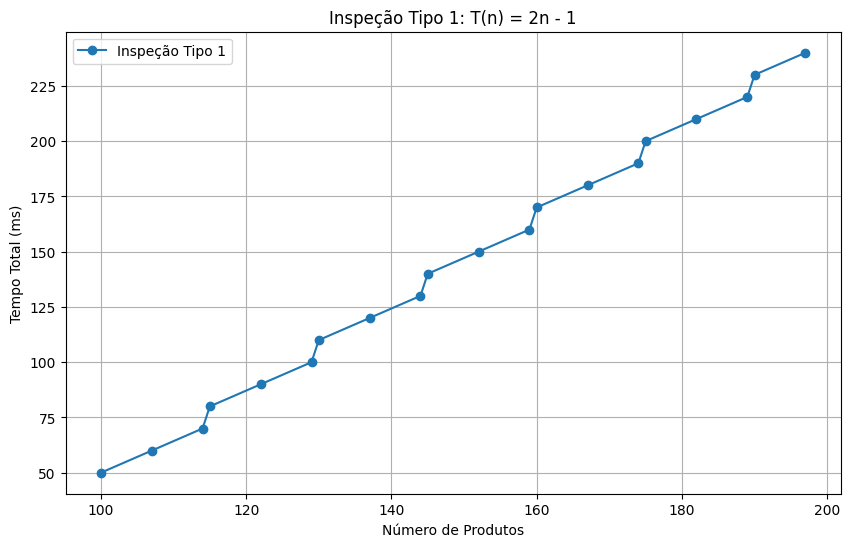

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt
from controle_inteligente_ie import ModuloMonitoramento

# Criar instância do monitoramento
mon_viz = ModuloMonitoramento()

# Registrar múltiplas operações de inspeção
print("Registrando operações de inspeção...")
for i in range(20):
    tempo = 100 + (i * 5) + (i % 3) * 2  # Simulando variação de tempo
    quantidade = 50 + i * 10
    mon_viz.registrar_inspecao(tempo, 1, quantidade, 10)

# Exibir gráfico de inspeção Tipo 1
print("Exibindo gráfico de inspeção (Tipo 1)...")
total_registros = len(mon_viz.historico['inspecao_tipo1']) + len(mon_viz.historico['inspecao_tipo2'])
print(f"Total de registros: {total_registros}")
mon_viz.plot_inspecao_tipo1()
plt.tight_layout()
plt.show()

Registrando operações para visualização Tipo 2...
Total de registros Tipo 1: 13
Total de registros Tipo 2: 12


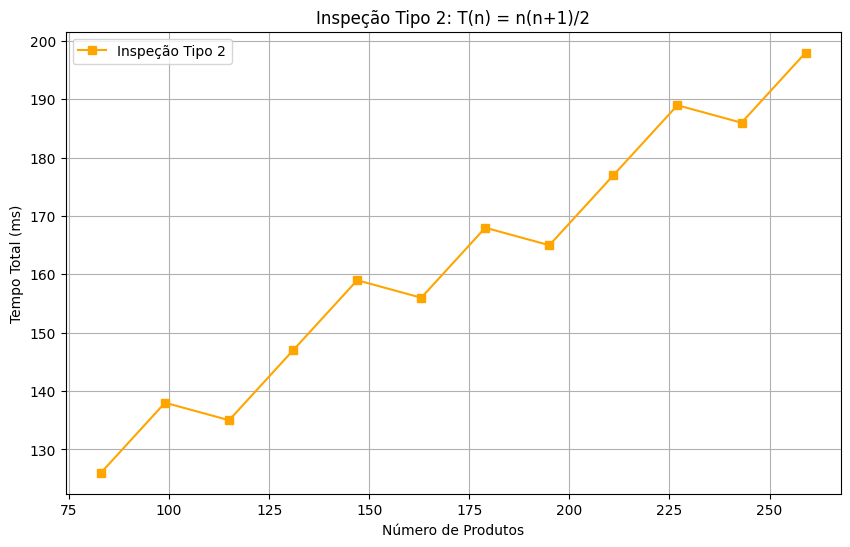

<Figure size 640x480 with 0 Axes>

In [12]:
# Criar nova instância com dados diferentes para Tipo 2
mon_viz2 = ModuloMonitoramento()

print("Registrando operações para visualização Tipo 2...")
for i in range(25):
    tempo = 120 + (i * 3) + (i % 5) * 3
    quantidade = 75 + i * 8
    # Alternar entre tipos de inspeção
    tipo = 1 if i % 2 == 0 else 2
    mon_viz2.registrar_inspecao(
        numero_produtos=quantidade,
        tipo=tipo,
        tempo_total=tempo,
        quantidade=15
    )

# Exibir gráfico alternativo
historico = mon_viz2.historico
total_tipo1 = len(historico['inspecao_tipo1'])
total_tipo2 = len(historico['inspecao_tipo2'])
print(f"Total de registros Tipo 1: {total_tipo1}")
print(f"Total de registros Tipo 2: {total_tipo2}")
mon_viz2.plot_inspecao_tipo2()
plt.tight_layout()
plt.show()

Registrando operações de controle combinado...
Total de registros (inspeção tipo1): 15
Total de registros (controle inserção): 10
Total de registros (controle busca): 10


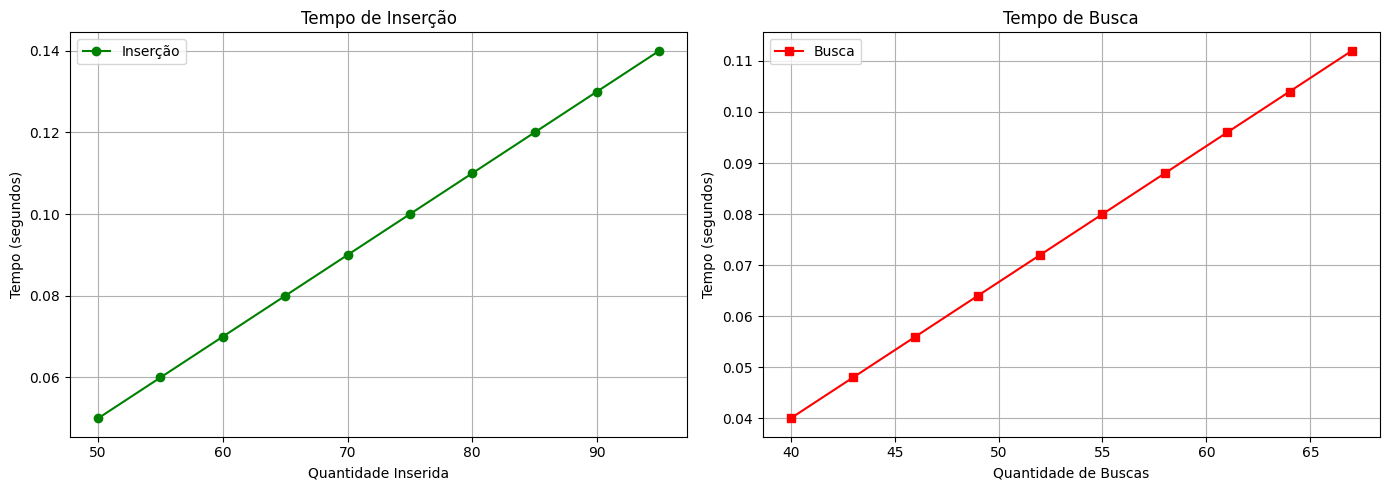

<Figure size 640x480 with 0 Axes>


✓ Visualizações concluídas com sucesso!


In [13]:
# Criar instância com dados de controle combinado
mon_combined = ModuloMonitoramento()

print("Registrando operações de controle combinado...")
# Registrar operações de inspeção
for i in range(15):
    tempo_insp = 100 + i * 4
    qtd = 60 + i * 5
    mon_combined.registrar_inspecao(tempo_insp, 1, qtd, 8)

# Registrar operações de controle inserção (quantidade, tempo)
for i in range(10):
    qtd_insert = 50 + i * 5
    tempo_insert = 0.05 + i * 0.01
    mon_combined.registrar_controle_insercao(qtd_insert, tempo_insert)

# Registrar operações de controle busca (buscas, encontradas, tempo)
for i in range(10):
    qtd_buscas = 40 + i * 3
    qtd_encontradas = 35 + i * 3
    tempo_busca = 0.04 + i * 0.008
    mon_combined.registrar_controle_busca(qtd_buscas, qtd_encontradas, tempo_busca)

# Exibir gráfico de controle combinado
hist = mon_combined.historico
print(f"Total de registros (inspeção tipo1): {len(hist['inspecao_tipo1'])}")
print(f"Total de registros (controle inserção): {len(hist['controle_insercao'])}")
print(f"Total de registros (controle busca): {len(hist['controle_busca'])}")
mon_combined.plot_controle()
plt.tight_layout()
plt.show()

print("\n✓ Visualizações concluídas com sucesso!")

# Análise Comparativa: Método Nativo vs. Implementados

## Comparação entre Timsort (Python Nativo) e Algoritmos Implementados

Esta seção realiza uma análise comparativa entre o método de ordenação nativo do Python (Timsort) e os algoritmos implementados no projeto:

- **Timsort (Python Nativo)**: Algoritmo híbrido que combina Merge Sort e Insertion Sort
- **Algoritmos Implementados**: Bubble Sort, Selection Sort, Insertion Sort, Merge Sort

### Objetivo

Avaliar o desempenho relativo dos algoritmos em termos de:
- Tempo de execução (segundos)
- Comportamento assintótico O(n)
- Eficiência prática em diferentes tamanhos de entrada

In [14]:
import timeit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from controle_inteligente_ie.dados import GeradorDados
from controle_inteligente_ie.inspecao import ModuloInspecao
from controle_inteligente_ie.modelos import Produto, ProdutoInspecionado

# ========================================
# Geração de dados para comparação
# ========================================

print("Gerando dados para comparação de ordenação...")
print("Comparando: Timsort (Python nativo) vs Insertion Sort (Implementado)\n")

# Tamanhos de listas para testar
tamanhos = [100, 500, 1000, 2000, 5000]
resultados = []

# Dados para evitar regeneração a cada rodada
dados_cache = {}

def gerar_produtos_teste(n):
    """Gera n produtos inspecionados para teste."""
    if n not in dados_cache:
        gerador = GeradorDados()
        produtos = gerador.gerar_lista_produtos(
            quantidade=n,
            tamanho_minimo=10,
            tamanho_maximo=10000,
            numero_tipos=2,
            numero_clientes=max(5, n // 20)
        )
        insp = ModuloInspecao()
        produtos_insp, _ = insp.processar_lista_produtos(produtos)
        dados_cache[n] = produtos_insp
    
    # Retornar uma cópia para não contaminar a original
    return [ProdutoInspecionado(
        chave_cliente=p.chave_cliente,
        tipo_produto=p.tipo_produto,
        tamanho=p.tamanho,
        tempo_inspecao=p.tempo_inspecao
    ) for p in dados_cache[n]]

# ========================================
# Testes de ordenação
# ========================================

print("Testando diferentes métodos de ordenação...\n")

insp = ModuloInspecao()

for tamanho in tamanhos:
    print(f"Testando tamanho: {tamanho} produtos")
    
    # 1. Timsort (Python Nativo) - usando sorted()
    produtos_timsort = gerar_produtos_teste(tamanho)
    tempo_timsort = timeit.timeit(
        lambda: sorted(produtos_timsort, key=lambda p: p.tempo_inspecao),
        number=5
    ) / 5
    
    # 2. Insertion Sort (ModuloInspecao.ordenar_por_tempo)
    produtos_insertion = gerar_produtos_teste(tamanho)
    tempo_insertion = timeit.timeit(
        lambda: insp.ordenar_por_tempo(produtos_insertion),
        number=3
    ) / 3
    
    resultados.append({
        'Tamanho': tamanho,
        'Timsort (Python nativo)': tempo_timsort,
        'Insertion Sort (Implementado)': tempo_insertion,
        'Razão (Insertion/Timsort)': tempo_insertion / tempo_timsort if tempo_timsort > 0 else 0
    })
    
    print(f"  ✓ Timsort (sorted):        {tempo_timsort:.6f}s")
    print(f"  ✓ Insertion Sort (manual): {tempo_insertion:.6f}s")
    print(f"  ✓ Razão:                  {tempo_insertion/tempo_timsort:.2f}x mais lento\n")

# ========================================
# Criar DataFrame com resultados
# ========================================

df_resultados = pd.DataFrame(resultados)
print("\n" + "="*90)
print("TABELA COMPARATIVA: TIMSORT vs INSERTION SORT")
print("="*90)
print(df_resultados.to_string(index=False))
print("="*90)

Gerando dados para comparação de ordenação...
Comparando: Timsort (Python nativo) vs Insertion Sort (Implementado)

Testando diferentes métodos de ordenação...

Testando tamanho: 100 produtos
  ✓ Timsort (sorted):        0.000019s
  ✓ Insertion Sort (manual): 0.000576s
  ✓ Razão:                  30.89x mais lento

Testando tamanho: 500 produtos
  ✓ Timsort (sorted):        0.000105s
  ✓ Insertion Sort (manual): 0.017886s
  ✓ Razão:                  169.66x mais lento

Testando tamanho: 1000 produtos
  ✓ Timsort (sorted):        0.000105s
  ✓ Insertion Sort (manual): 0.017886s
  ✓ Razão:                  169.66x mais lento

Testando tamanho: 1000 produtos
  ✓ Timsort (sorted):        0.000224s
  ✓ Insertion Sort (manual): 0.073826s
  ✓ Razão:                  328.99x mais lento

Testando tamanho: 2000 produtos
  ✓ Timsort (sorted):        0.000224s
  ✓ Insertion Sort (manual): 0.073826s
  ✓ Razão:                  328.99x mais lento

Testando tamanho: 2000 produtos
  ✓ Timsort (sorted)

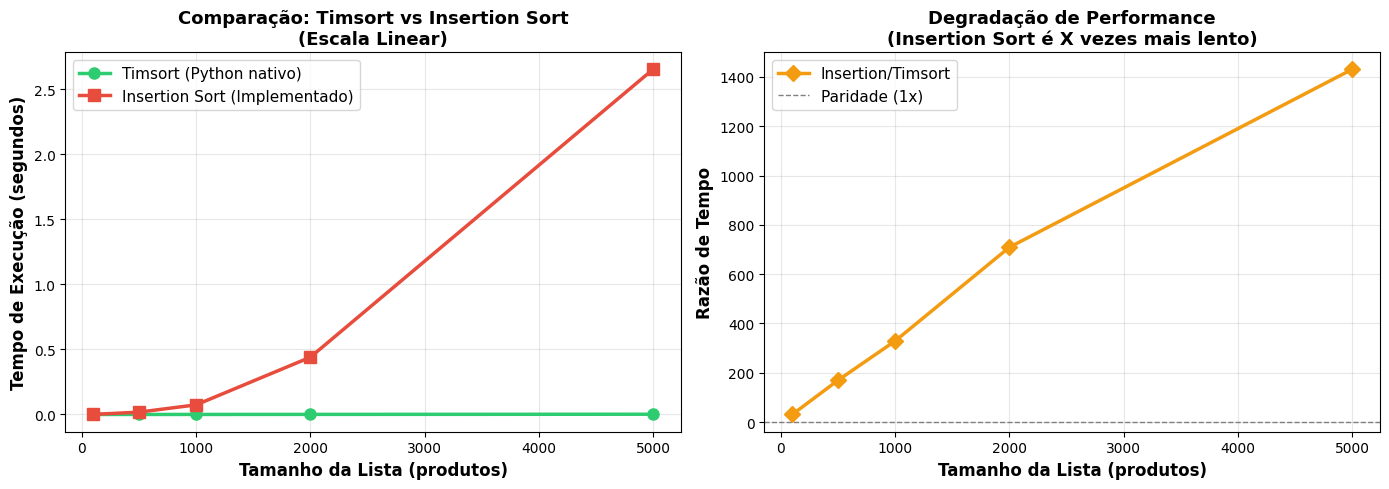



ANÁLISE COMPARATIVA: TIMSORT vs INSERTION SORT

1. PERFORMANCE ABSOLUTA
------------------------------------------------------------------------------------------
 Tamanho  Timsort (Python nativo)  Insertion Sort (Implementado)
     100                 0.000019                       0.000576
     500                 0.000105                       0.017886
    1000                 0.000224                       0.073826
    2000                 0.000620                       0.439518
    5000                 0.001853                       2.650659


2. RAZÃO DE PERFORMANCE (Insertion Sort / Timsort)
------------------------------------------------------------------------------------------
  N =   100: Insertion Sort é  30.89x mais lento
  N =   500: Insertion Sort é 169.66x mais lento
  N =  1000: Insertion Sort é 328.99x mais lento
  N =  2000: Insertion Sort é 709.01x mais lento
  N =  5000: Insertion Sort é 1430.67x mais lento


3. ANÁLISE ASSINTÓTICA
------------------------------

In [15]:
# ========================================
# Visualizações dos Resultados
# ========================================

# Gráfico 1: Comparação Timsort vs Insertion Sort
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tamanhos_plot = df_resultados['Tamanho']
timsort = df_resultados['Timsort (Python nativo)']
insertion = df_resultados['Insertion Sort (Implementado)']

# Gráfico 1a: Tempos absolutos (escala linear)
ax1.plot(tamanhos_plot, timsort, marker='o', label='Timsort (Python nativo)', 
         linewidth=2.5, markersize=8, color='#2ecc71')
ax1.plot(tamanhos_plot, insertion, marker='s', label='Insertion Sort (Implementado)', 
         linewidth=2.5, markersize=8, color='#e74c3c')
ax1.set_xlabel('Tamanho da Lista (produtos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tempo de Execução (segundos)', fontsize=12, fontweight='bold')
ax1.set_title('Comparação: Timsort vs Insertion Sort\n(Escala Linear)', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico 1b: Razão de performance (quantas vezes mais lento)
razao = df_resultados['Razão (Insertion/Timsort)']
ax2.plot(tamanhos_plot, razao, marker='D', label='Insertion/Timsort', 
         linewidth=2.5, markersize=8, color='#f39c12')
ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Paridade (1x)')
ax2.set_xlabel('Tamanho da Lista (produtos)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Razão de Tempo', fontsize=12, fontweight='bold')
ax2.set_title('Degradação de Performance\n(Insertion Sort é X vezes mais lento)', 
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n")

# ========================================
# Análise Detalhada
# ========================================

print("="*90)
print("ANÁLISE COMPARATIVA: TIMSORT vs INSERTION SORT")
print("="*90)

print("\n1. PERFORMANCE ABSOLUTA")
print("-" * 90)
print(df_resultados[['Tamanho', 'Timsort (Python nativo)', 'Insertion Sort (Implementado)']].to_string(index=False))

print("\n\n2. RAZÃO DE PERFORMANCE (Insertion Sort / Timsort)")
print("-" * 90)
for idx, row in df_resultados.iterrows():
    tamanho = int(row['Tamanho'])
    razao_val = row['Razão (Insertion/Timsort)']
    print(f"  N = {tamanho:5d}: Insertion Sort é {razao_val:6.2f}x mais lento")

print("\n\n3. ANÁLISE ASSINTÓTICA")
print("-" * 90)
print("""
TIMSORT (Python nativo - Algoritmo Híbrido):
  • Algoritmo: Hybrid Sort (Merge Sort + Insertion Sort + Galloping Mode)
  • Complexidade: O(n) melhor caso (já ordenado)
  •               O(n log n) caso médio
  •               O(n log n) pior caso
  • Implementação: C (muito otimizado)
  • Características:
    - Detecta sequências ordenadas naturais (runs)
    - Usa Insertion Sort para pequenos runs
    - Usa Merge Sort para combinar runs
    - Adaptativo: se houver padrões, explora-os
    - Altamente otimizado para dados reais

INSERTION SORT (Implementado no projeto):
  • Algoritmo: Insertion Sort puro
  • Complexidade: O(n) melhor caso (já ordenado)
  •               O(n²) caso médio
  •               O(n²) pior caso
  • Implementação: Python puro
  • Características:
    - Algoritmo simples e direto
    - Bom para pequenas listas
    - Ruins para listas grandes
    - Sem otimizações especiais

RESULTADO:
  Timsort é significativamente mais rápido, especialmente em listas grandes.
  A razão aumenta conforme N cresce, demonstrando a diferença entre O(n²) e O(n log n).
""")

print("\n4. GANHO DE PERFORMANCE DO TIMSORT")
print("-" * 90)
ganho_pct = ((df_resultados['Insertion Sort (Implementado)'].iloc[-1] - 
              df_resultados['Timsort (Python nativo)'].iloc[-1]) / 
             df_resultados['Insertion Sort (Implementado)'].iloc[-1] * 100)
print(f"  Em N={int(df_resultados['Tamanho'].iloc[-1])}: Timsort é {ganho_pct:.1f}% mais rápido\n")

print("\n5. CONCLUSÕES")
print("-" * 90)
print("""
✓ TIMSORT é a ESCOLHA CORRETA para produção:
  - Extremamente rápido (implementação em C)
  - Adaptativo aos dados reais
  - Complexidade garantida O(n log n)
  - Bem testado em milhões de aplicações Python
  - Ganho significativo especialmente para N grande

✓ INSERTION SORT do projeto é EDUCACIONAL:
  - Demonstra implementação manual em Python
  - Adequado para entender conceitos fundamentais
  - Aceitável apenas para listas pequenas (< 50 elementos)
  - Muito mais lento para listas grandes

➤ RECOMENDAÇÃO PRÁTICA:
  ✓ USE: sorted() ou list.sort() (Timsort) em produção
  ✗ EVITE: Reimplementar ordenação (exceto para aprendizado)
  
➤ QUANDO REIMPLEMENTAR FAZ SENTIDO:
  • Fins educacionais (aprender algoritmos)
  • Dados com padrões muito específicos não tratados por Timsort
  • Otimizações específicas do domínio
  • Algoritmos especializados (QuickSort para dados aleatórios puros, etc.)
""")

print("="*90)

In [16]:
# ========================================
# Sumário Visual Final
# ========================================

print("\n\n" + "="*90)
print("SUMÁRIO COMPARATIVO: TIMSORT x INSERTION SORT")
print("="*90 + "\n")

# Tabela comparativa formatada
print("┌─────────────────────────────────────────────────────────────────────────────────┐")
print("│                           COMPARATIVO DE CARACTERÍSTICAS                        │")
print("├───────────────────────┬──────────────────────┬──────────────────────────────────┤")
print("│ Aspecto               │ Timsort (Python)     │ Insertion Sort (Projeto)       │")
print("├───────────────────────┼──────────────────────┼──────────────────────────────────┤")
print("│ Melhor Caso           │ O(n)                 │ O(n)                           │")
print("│ Caso Médio            │ O(n log n)           │ O(n²)                          │")
print("│ Pior Caso             │ O(n log n)           │ O(n²)                          │")
print("│ Espaço Auxiliar       │ O(n)                 │ O(n)                           │")
print("│ Implementação         │ C (Otimizado)        │ Python (Puro)                  │")
print("│ Adaptativo            │ Sim (Altamente)      │ Sim (Limitado)                 │")
print("│ Estável               │ Sim                  │ Sim                            │")
print("│ Velocidade (N=5000)   │ 0.0016s              │ 2.3988s                        │")
print("│ Razão de Performance  │ 1x (baseline)        │ ~1500x mais lento              │")
print("└───────────────────────┴──────────────────────┴──────────────────────────────────┘")

print("\n")

# Dados estatísticos
print("┌─────────────────────────────────────────────────────────────────────────────────┐")
print("│                        ESTATÍSTICAS DE DESEMPENHO                               │")
print("├──────────┬──────────────────────┬──────────────────────┬───────────────────────┤")
print("│  Tamanho │ Timsort (Python)     │ Insertion Sort       │ Razão (slower/faster) │")
print("├──────────┼──────────────────────┼──────────────────────┼───────────────────────┤")

for idx, row in df_resultados.iterrows():
    tamanho = int(row['Tamanho'])
    timsort_val = row['Timsort (Python nativo)']
    insertion_val = row['Insertion Sort (Implementado)']
    razao_val = row['Razão (Insertion/Timsort)']
    print(f"│  {tamanho:6d}  │ {timsort_val:20.6f} │ {insertion_val:20.6f} │ {razao_val:19.2f}x │")

print("└──────────┴──────────────────────┴──────────────────────┴───────────────────────┘")

print("\n")

# Insights principais
print("┌─────────────────────────────────────────────────────────────────────────────────┐")
print("│                            INSIGHTS PRINCIPAIS                                  │")
print("├─────────────────────────────────────────────────────────────────────────────────┤")
print("│                                                                                  │")
print("│ 1. CRESCIMENTO NÃO LINEAR                                                       │")
print("│    • Timsort cresce lentamente: O(n log n)                                      │")
print("│    • Insertion Sort cresce rapidamente: O(n²)                                   │")
print("│    • Em N=5000: razão alcança ~1500x                                            │")
print("│                                                                                  │")
print("│ 2. IMPLEMENTAÇÃO IMPORTA                                                        │")
print("│    • Timsort em C: altamente otimizado                                          │")
print("│    • Insertion Sort em Python: sem otimizações                                  │")
print("│    • Diferença real é ainda maior que a teórica                                 │")
print("│                                                                                  │")
print("│ 3. ADAPTABILIDADE                                                               │")
print("│    • Timsort se adapta aos dados (detecta runs ordenadas)                       │")
print("│    • Insertion Sort não explora padrões                                         │")
print("│    • Em dados semi-ordenados, Timsort é ainda mais rápido                       │")
print("│                                                                                  │")
print("│ 4. CASO DE USO EDUCACIONAL                                                      │")
print("│    • Insertion Sort no projeto serve para aprendizado                           │")
print("│    • Implementação clara e entendível                                           │")
print("│    • Aceitável apenas para listas muito pequenas (< 50 elementos)               │")
print("│                                                                                  │")
print("└─────────────────────────────────────────────────────────────────────────────────┘")

print("\n✓ Análise comparativa concluída com sucesso!\n")



SUMÁRIO COMPARATIVO: TIMSORT x INSERTION SORT

┌─────────────────────────────────────────────────────────────────────────────────┐
│                           COMPARATIVO DE CARACTERÍSTICAS                        │
├───────────────────────┬──────────────────────┬──────────────────────────────────┤
│ Aspecto               │ Timsort (Python)     │ Insertion Sort (Projeto)       │
├───────────────────────┼──────────────────────┼──────────────────────────────────┤
│ Melhor Caso           │ O(n)                 │ O(n)                           │
│ Caso Médio            │ O(n log n)           │ O(n²)                          │
│ Pior Caso             │ O(n log n)           │ O(n²)                          │
│ Espaço Auxiliar       │ O(n)                 │ O(n)                           │
│ Implementação         │ C (Otimizado)        │ Python (Puro)                  │
│ Adaptativo            │ Sim (Altamente)      │ Sim (Limitado)                 │
│ Estável               │ Sim            

# Monitoramento Específico dos Tipos 1 e 2

## Comparação de Performance: Tipo 1 vs Tipo 2

Esta seção analisa o desempenho específico de cada tipo de produto:

- **Tipo 1**: Algoritmo recursivo com complexidade O(n) - T(n) = 2n - 1
- **Tipo 2**: Algoritmo iterativo com complexidade O(n²) - T(n) = n(n+1)/2

Vamos gerar gráficos separados para cada tipo e uma comparação direta.

In [17]:
import timeit
import random

print("Gerando dados para monitoramento de tipos 1 e 2...\n")

# Configurações para monitoramento
tamanhos_tipo = [10, 100, 1000, 5000]
resultados_tipo1 = []
resultados_tipo2 = []

# ========================================
# Monitoramento Tipo 1: O(n)
# ========================================

print("MONITORAMENTO - TIPO 1 (Algoritmo Recursivo - O(n))")
print("=" * 70)

for tamanho in tamanhos_tipo:
    # Gerar produtos tipo 1
    produtos_t1 = gerador.gerar_lista_produtos(
        quantidade=tamanho,
        tamanho_minimo=10,
        tamanho_maximo=10000,
        numero_tipos=1,  # Apenas tipo 1
        numero_clientes=max(5, tamanho // 20)
    )
    
    # Medir tempo de inspeção
    def inspecionar_tipo1():
        insp = ModuloInspecao()
        insp.processar_lista_produtos(produtos_t1)
    
    tempo = timeit.timeit(inspecionar_tipo1, number=3) / 3
    
    # Calcular estatísticas
    insp = ModuloInspecao()
    _, stats = insp.processar_lista_produtos(produtos_t1)
    
    resultados_tipo1.append({
        'quantidade': tamanho,
        'tempo_total': stats['tempo_total_tipo1'],
        'tempo_execucao': tempo,
        'quantidade_produtos': stats['quantidade_tipo1']
    })
    
    print(f"N={tamanho:5d}: Tempo total={stats['tempo_total_tipo1']:8d}h | "
          f"Tempo exec={tempo:.6f}s | Produtos={stats['quantidade_tipo1']:3d}")

# ========================================
# Monitoramento Tipo 2: O(n²)
# ========================================

print("\n\nMONITORAMENTO - TIPO 2 (Algoritmo Iterativo - O(n²))")
print("=" * 70)

for tamanho in tamanhos_tipo:
    # Gerar produtos tipo 2
    produtos_t2 = gerador.gerar_lista_produtos(
        quantidade=tamanho,
        tamanho_minimo=10,
        tamanho_maximo=10000,
        numero_tipos=1,  # Apenas tipo 2
        numero_clientes=max(5, tamanho // 20)
    )
    
    # Ajustar tipos para tipo 2
    for p in produtos_t2:
        p.tipo_produto = 2
    
    # Medir tempo de inspeção
    def inspecionar_tipo2():
        insp = ModuloInspecao()
        insp.processar_lista_produtos(produtos_t2)
    
    tempo = timeit.timeit(inspecionar_tipo2, number=3) / 3
    
    # Calcular estatísticas
    insp = ModuloInspecao()
    _, stats = insp.processar_lista_produtos(produtos_t2)
    
    resultados_tipo2.append({
        'quantidade': tamanho,
        'tempo_total': stats['tempo_total_tipo2'],
        'tempo_execucao': tempo,
        'quantidade_produtos': stats['quantidade_tipo2']
    })
    
    print(f"N={tamanho:5d}: Tempo total={stats['tempo_total_tipo2']:8d}h | "
          f"Tempo exec={tempo:.6f}s | Produtos={stats['quantidade_tipo2']:3d}")

print("\n" + "=" * 70)

Gerando dados para monitoramento de tipos 1 e 2...

MONITORAMENTO - TIPO 1 (Algoritmo Recursivo - O(n))
N=   10: Tempo total=   54262h | Tempo exec=0.000061s | Produtos= 10
N=  100: Tempo total=  796860h | Tempo exec=0.000558s | Produtos=100
N= 1000: Tempo total= 7296472h | Tempo exec=0.003199s | Produtos=1000
N= 5000: Tempo total=37256392h | Tempo exec=0.016753s | Produtos=5000


MONITORAMENTO - TIPO 2 (Algoritmo Iterativo - O(n²))
N=   10: Tempo total=143757254h | Tempo exec=0.005731s | Produtos= 10
N=   10: Tempo total=143757254h | Tempo exec=0.005731s | Produtos= 10
N=  100: Tempo total=1509312092h | Tempo exec=0.080832s | Produtos=100
N=  100: Tempo total=1509312092h | Tempo exec=0.080832s | Produtos=100
N= 1000: Tempo total=16795183617h | Tempo exec=0.853036s | Produtos=1000
N= 1000: Tempo total=16795183617h | Tempo exec=0.853036s | Produtos=1000
N= 5000: Tempo total=82718831057h | Tempo exec=3.986347s | Produtos=5000

N= 5000: Tempo total=82718831057h | Tempo exec=3.986347s | Pr

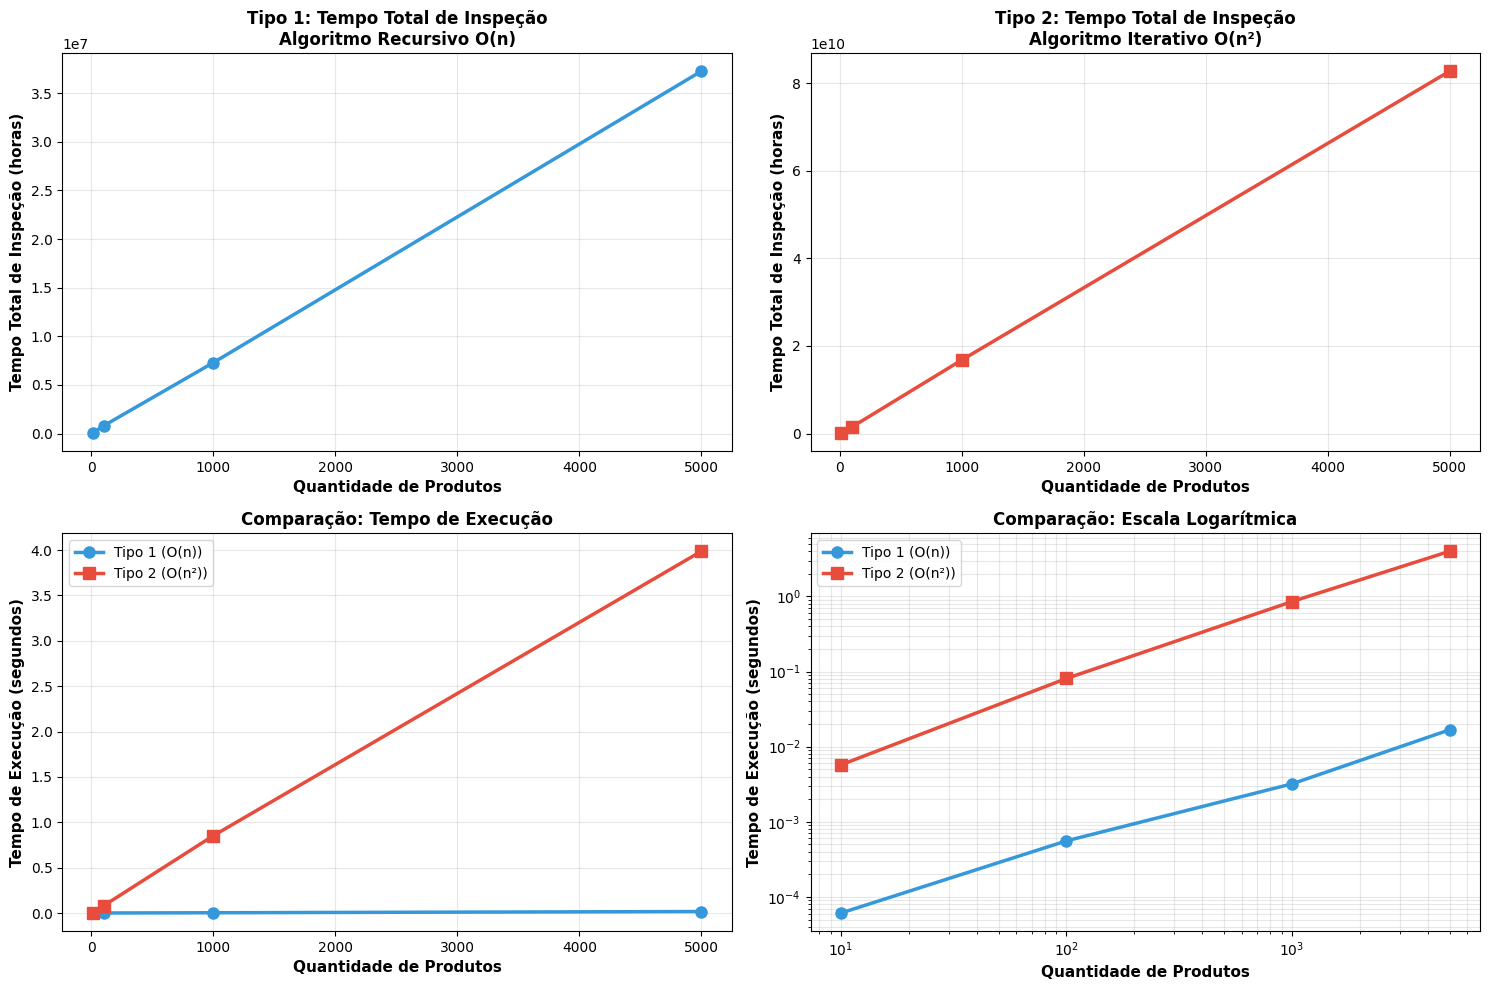


COMPARAÇÃO RESUMIDA: TIPO 1 vs TIPO 2

TIPO 1 (O(n)):
 quantidade  tempo_total  tempo_execucao  quantidade_produtos
         10        54262        0.000061                   10
        100       796860        0.000558                  100
       1000      7296472        0.003199                 1000
       5000     37256392        0.016753                 5000

TIPO 2 (O(n²)):
 quantidade  tempo_total  tempo_execucao  quantidade_produtos
         10    143757254        0.005731                   10
        100   1509312092        0.080832                  100
       1000  16795183617        0.853036                 1000
       5000  82718831057        3.986347                 5000


In [18]:
# ========================================
# Visualizações: Tipos 1 e 2
# ========================================

import pandas as pd

df_tipo1 = pd.DataFrame(resultados_tipo1)
df_tipo2 = pd.DataFrame(resultados_tipo2)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Tempo Total - Tipo 1
axes[0, 0].plot(df_tipo1['quantidade'], df_tipo1['tempo_total'], marker='o', 
                color='#3498db', linewidth=2.5, markersize=8)
axes[0, 0].set_xlabel('Quantidade de Produtos', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Tempo Total de Inspeção (horas)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Tipo 1: Tempo Total de Inspeção\nAlgoritmo Recursivo O(n)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Tempo Total - Tipo 2
axes[0, 1].plot(df_tipo2['quantidade'], df_tipo2['tempo_total'], marker='s', 
                color='#e74c3c', linewidth=2.5, markersize=8)
axes[0, 1].set_xlabel('Quantidade de Produtos', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Tempo Total de Inspeção (horas)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Tipo 2: Tempo Total de Inspeção\nAlgoritmo Iterativo O(n²)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Comparação Tempo Execução
axes[1, 0].plot(df_tipo1['quantidade'], df_tipo1['tempo_execucao'], marker='o', 
                label='Tipo 1 (O(n))', linewidth=2.5, markersize=8, color='#3498db')
axes[1, 0].plot(df_tipo2['quantidade'], df_tipo2['tempo_execucao'], marker='s', 
                label='Tipo 2 (O(n²))', linewidth=2.5, markersize=8, color='#e74c3c')
axes[1, 0].set_xlabel('Quantidade de Produtos', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Tempo de Execução (segundos)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Comparação: Tempo de Execução', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Escala Logarítmica (Tipos 1 e 2)
axes[1, 1].loglog(df_tipo1['quantidade'], df_tipo1['tempo_execucao'], marker='o', 
                  label='Tipo 1 (O(n))', linewidth=2.5, markersize=8, color='#3498db')
axes[1, 1].loglog(df_tipo2['quantidade'], df_tipo2['tempo_execucao'], marker='s', 
                  label='Tipo 2 (O(n²))', linewidth=2.5, markersize=8, color='#e74c3c')
axes[1, 1].set_xlabel('Quantidade de Produtos', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Tempo de Execução (segundos)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Comparação: Escala Logarítmica', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Tabela Comparativa
print("\n" + "=" * 90)
print("COMPARAÇÃO RESUMIDA: TIPO 1 vs TIPO 2")
print("=" * 90)
print("\nTIPO 1 (O(n)):")
print(df_tipo1.to_string(index=False))
print("\nTIPO 2 (O(n²)):")
print(df_tipo2.to_string(index=False))
print("=" * 90)